
# Decision Tree Implementation using Scikit-Learn

## Problem Definition

The objective of this project is to build and visualize a **Decision Tree Model**
using Scikit-Learn for classification.

### Objectives
- Load and explore a dataset
- Train a Decision Tree Classifier
- Evaluate model performance
- Visualize the Decision Tree
- Analyze feature importance

### Algorithm Used
- Decision Tree Classifier

### Dataset Used
- Iris Dataset from Scikit-Learn

### Evaluation Metrics
- Accuracy Score
- Classification Report
- Confusion Matrix


In [1]:

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')


In [2]:

# Load Dataset

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(iris.target)

print("Dataset Shape:", X.shape)

X.head()


Dataset Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:

# Dataset Information

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)


Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']


In [4]:

# Check Missing Values

print(X.isnull().sum())


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [5]:

# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (120, 4)
Testing Shape: (30, 4)


In [6]:

# Train Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully.")


Model Trained Successfully.


In [7]:

# Make Predictions

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)


Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [8]:

# Evaluate Model Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)


Accuracy Score: 1.0


In [9]:

# Classification Report

report = classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
)

print(report)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



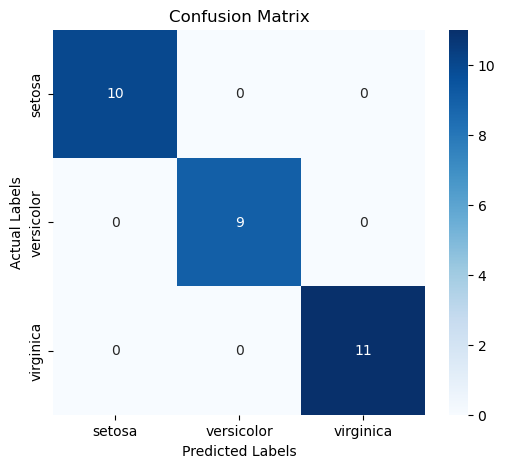

In [10]:

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.show()


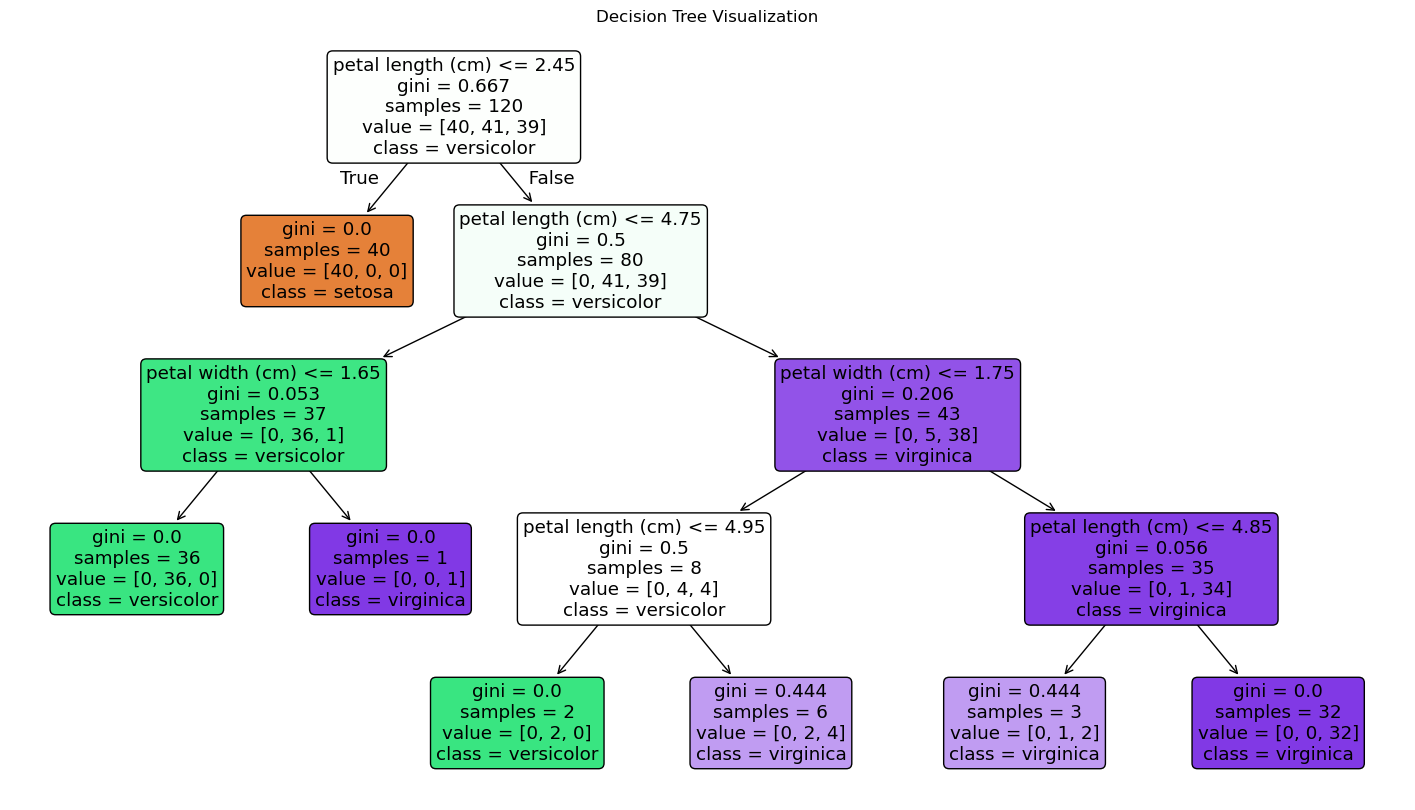

In [11]:

# Visualize Decision Tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")

plt.show()


In [12]:

# Feature Importance Analysis

feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)


             Feature  Importance
2  petal length (cm)    0.936298
3   petal width (cm)    0.063702
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


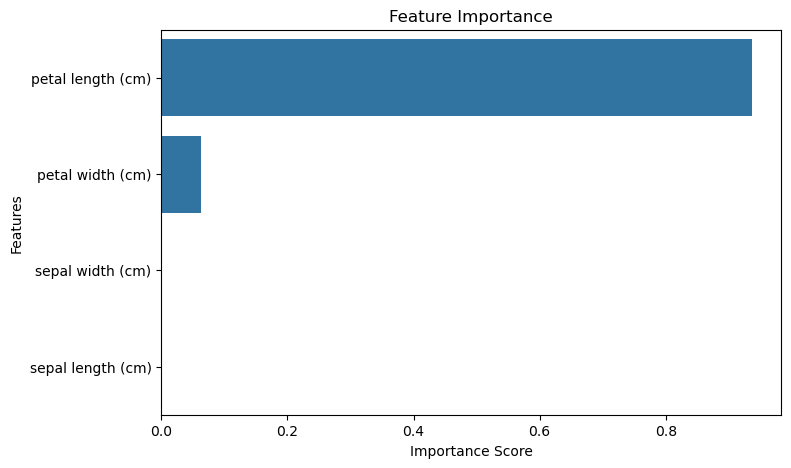

In [13]:

# Visualize Feature Importance

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()



# Model Analysis

## Observations

- The Decision Tree model classified the Iris flower species effectively.
- The visualization clearly shows decision-making rules.
- Some features contributed more to prediction than others.

## Advantages of Decision Trees

- Easy to understand
- Easy to visualize
- Requires less data preprocessing

## Limitations

- Can overfit the dataset
- Sensitive to noisy data

## Improvements

- Hyperparameter tuning
- Tree pruning
- Ensemble techniques like Random Forest



# Conclusion

In this project:

- A Decision Tree Classifier was implemented successfully.
- The model was trained and tested on the Iris dataset.
- Model performance was evaluated using classification metrics.
- Decision Tree visualization and feature importance analysis were performed.

Decision Trees are widely used because they are simple, interpretable,
and effective for many classification and prediction problems.
